# Activation analysis
Grayscale variant of Driver Model

In [ ]:
import random
import os
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

INPUT_SIZE = 224
N_SAMPLES  = 10

ROOT      = Path("../../")
DATASET   = ROOT / "dataset"
MODEL_PTH = Path("driver_model_gray.pth")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Dataset: {DATASET.resolve()}")
print(f"Model:   {MODEL_PTH.resolve()}")

## 1 - Model

In [18]:
class DriverModelGray(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1   = nn.Conv2d(1, 16, kernel_size=5, stride=2)
        self.conv2   = nn.Conv2d(16, 32, kernel_size=5, stride=2)
        self.conv3   = nn.Conv2d(32, 64, kernel_size=5, stride=2)
        self.dropout = nn.Dropout(p=0.4)
        self.fc1     = nn.Linear(40000, 256)
        self.fc2     = nn.Linear(256, 2)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = torch.relu(self.conv3(x))
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)


def load_model(path, device):
    model = DriverModelGray()
    obj = torch.load(path, map_location=device, weights_only=False)
    state = obj.state_dict() if isinstance(obj, nn.Module) else obj
    model.load_state_dict(state)
    return model.to(device).eval()


model = load_model(MODEL_PTH, device)
print("Model loaded.", sum(p.numel() for p in model.parameters()), "params")

Model loaded. 10305282 params


## 2 - Dataset

In [19]:
records = []  # list of {path, forward, turn}

for csv_path in sorted(DATASET.glob("*.csv")):
    session_dir = csv_path.with_suffix("")   # same name, no .csv
    if not session_dir.is_dir():
        continue
    df = pd.read_csv(csv_path)
    for _, row in df.iterrows():
        img_path = session_dir / row["img_id"]
        if img_path.exists():
            records.append({
                "path":    img_path,
                "forward": float(row["forward"]),
                "turn":    float(row["turn"]),
            })

print(f"Total samples found: {len(records)}")
sample_records = random.sample(records, min(N_SAMPLES, len(records)))
print(f"Selected {len(sample_records)} random images for analysis.")

Total samples found: 7694
Selected 10 random images for analysis.


## 3 - Pre-processing helpers

In [20]:
# Grayscale normalisation stats (luminance approximation of ImageNet)
_MEAN = torch.tensor([0.449], device=device).view(1, 1, 1, 1)
_STD  = torch.tensor([0.226], device=device).view(1, 1, 1, 1)


def preprocess(bgr_img):
    """BGR uint8 (H,W,3) → normalised grayscale tensor (1,1,H,W)"""
    img  = cv2.resize(bgr_img, (INPUT_SIZE, INPUT_SIZE))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)          # (H, W) uint8
    t    = torch.from_numpy(gray).float().div(255.0)      # (H, W)
    t    = t.unsqueeze(0).unsqueeze(0).to(device)         # (1, 1, H, W)
    t    = (t - _MEAN) / _STD
    return t


def load_bgr(path):
    img = cv2.imread(str(path))
    if img is None:
        raise FileNotFoundError(path)
    return img

## 4 - GradCAM implementation

In [21]:
class GradCAM:
    """Minimal GradCAM — works for any model with a named target layer."""

    def __init__(self, model, target_layer):
        self.model = model
        self._acts  = None
        self._grads = None

        target_layer.register_forward_hook(self._save_acts)
        target_layer.register_full_backward_hook(self._save_grads)

    def _save_acts(self, _mod, _inp, out):
        self._acts = out.detach()

    def _save_grads(self, _mod, _inp, out):
        self._grads = out[0].detach()

    def __call__(self, tensor, output_idx):
        """
        Returns a (H, W) numpy saliency map in [0, 1].
        output_idx: 0 = forward, 1 = turn
        """
        self.model.zero_grad()
        out = self.model(tensor)          # (1, 2)
        scalar = out[0, output_idx]
        scalar.backward()

        weights = self._grads.mean(dim=(2, 3), keepdim=True)   # (1, 64, 1, 1)
        cam = (weights * self._acts).sum(dim=1, keepdim=True)  # (1, 1, 25, 25)
        cam = F.relu(cam)
        cam = cam.squeeze().cpu().numpy()

        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        else:
            cam = np.zeros_like(cam)

        return cam


# conv3 is the last spatial layer — output (64, 25, 25) before flatten
target_layer = model.conv3
gradcam = GradCAM(model, target_layer)
print("GradCAM target layer:", target_layer)

GradCAM target layer: Conv2d(32, 64, kernel_size=(5, 5), stride=(2, 2))


## 5 - Overlay helper

In [22]:
def overlay_cam(bgr_img, cam, alpha=0.45):
    """Overlay a GradCAM heatmap onto a BGR image; returns RGB uint8."""
    rgb  = cv2.cvtColor(cv2.resize(bgr_img, (INPUT_SIZE, INPUT_SIZE)), cv2.COLOR_BGR2RGB)
    heat = cv2.resize(cam, (INPUT_SIZE, INPUT_SIZE))
    heat_uint8 = np.uint8(255 * heat)
    colormap   = cv2.applyColorMap(heat_uint8, cv2.COLORMAP_JET)
    colormap   = cv2.cvtColor(colormap, cv2.COLOR_BGR2RGB)
    blended    = (alpha * colormap.astype(float) + (1 - alpha) * rgb.astype(float))
    return np.uint8(np.clip(blended, 0, 255))

## 6 - Analysis

In [23]:
results = []

for rec in sample_records:
    bgr = load_bgr(rec["path"])
    tensor = preprocess(bgr).requires_grad_(False)

    # --- forward pass for prediction (no grad needed) ---
    with torch.no_grad():
        pred = model(tensor).squeeze().cpu().numpy()

    # --- GradCAM for FORWARD output ---
    tensor_f = preprocess(bgr)  # fresh tensor, needs grad
    cam_fwd  = gradcam(tensor_f, output_idx=0)

    # --- GradCAM for TURN output ---
    tensor_t = preprocess(bgr)
    cam_turn = gradcam(tensor_t, output_idx=1)

    rgb_orig     = cv2.cvtColor(cv2.resize(bgr, (INPUT_SIZE, INPUT_SIZE)), cv2.COLOR_BGR2RGB)
    overlay_fwd  = overlay_cam(bgr, cam_fwd)
    overlay_turn = overlay_cam(bgr, cam_turn)

    results.append({
        "name":         rec["path"].name,
        "gt_forward":   rec["forward"],
        "gt_turn":      rec["turn"],
        "pred_forward": float(pred[0]),
        "pred_turn":    float(pred[1]),
        "rgb":          rgb_orig,
        "overlay_fwd":  overlay_fwd,
        "overlay_turn": overlay_turn,
    })

print(f"Processed {len(results)} images.")

Processed 10 images.


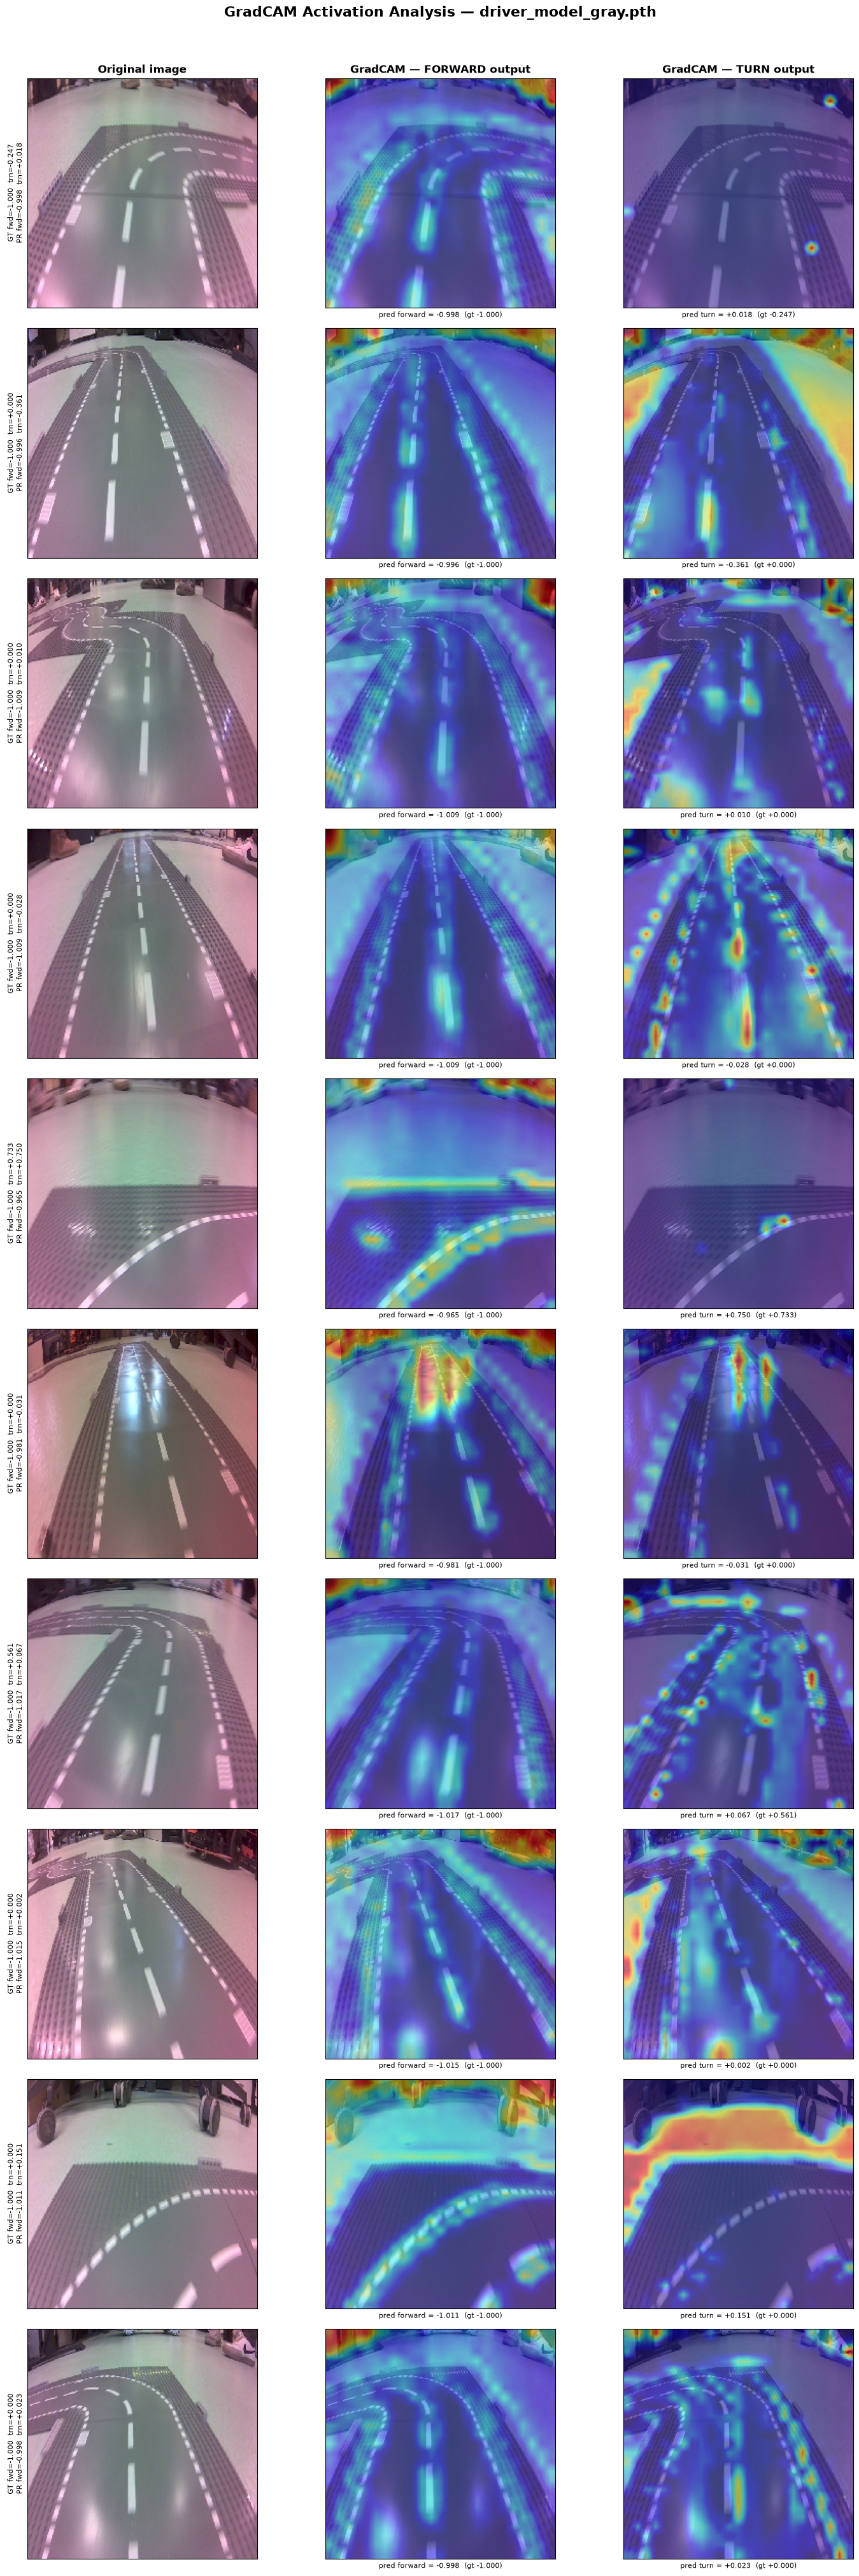

Saved → activation_analysis.png


In [24]:
fig, axes = plt.subplots(N_SAMPLES, 3, figsize=(15, N_SAMPLES * 4))
fig.suptitle("GradCAM Activation Analysis — driver_model_gray.pth", fontsize=16, fontweight="bold", y=1.01)

col_titles = ["Original image", "GradCAM — FORWARD output", "GradCAM — TURN output"]
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=12, fontweight="bold")

for i, r in enumerate(results):
    row = axes[i]

    row[0].imshow(r["rgb"])
    row[0].set_ylabel(
        f"GT fwd={r['gt_forward']:+.3f}  trn={r['gt_turn']:+.3f}\n"
        f"PR fwd={r['pred_forward']:+.3f}  trn={r['pred_turn']:+.3f}",
        fontsize=8, labelpad=4,
    )

    row[1].imshow(r["overlay_fwd"])
    row[1].set_xlabel(
        f"pred forward = {r['pred_forward']:+.3f}  (gt {r['gt_forward']:+.3f})",
        fontsize=8,
    )

    row[2].imshow(r["overlay_turn"])
    row[2].set_xlabel(
        f"pred turn = {r['pred_turn']:+.3f}  (gt {r['gt_turn']:+.3f})",
        fontsize=8,
    )

    for ax in row:
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.savefig("activation_analysis.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → activation_analysis.png")